# Notebook CNN

El objetivo de este notebook es comparar empíricamente una red totalmente conectada (multilayer precepton) con una red convolucional simple (CNN) sobre los datos de MNIST. Vamos a comparar la dinámica de entrenamiento, la generalización y la eficiencia por parámetro. 


### Reproducibilidad y dispositivo
- `set_seed(seed)` fija semillas para `numpy`, `random` y `torch`. En GPU puede haber fuentes de no-determinismo (cuDNN), por lo que para reproducibilidad estricta habría que añadir flags adicionales (a costa de rendimiento).
- `find_device()` detecta y usa GPU (CUDA) si está disponible, luego MPS (Apple Silicon) y finalmente CPU.
- `get_data_dir()` intenta escribir en `./data` y si el sistema es de solo lectura usará un directorio temporal.

In [1]:
# ---------------------------
# Imports & utilidades básicas
# ---------------------------
import os
import tempfile
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns



# ---------------------------
# Reproducibilidad y dispositivo
# ---------------------------
def set_seed(seed=1234):
    """
    Fija semillas para reproducibilidad (numpy, random y torch).
    Nota: reproducibilidad absoluta en GPU puede requerir flags adicionales.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def find_device():
    """
    Detecta el mejor device disponible:
      CUDA > MPS (Apple) > CPU
    Nota: usamos llamadas correctas a los checkers (con paréntesis).
    """
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

# seleccionar device y fijar semilla global por defecto
DEVICE = find_device()
print("DEVICE:", DEVICE)
SEED = 1234
set_seed(SEED)

def get_data_dir(preferred='./data'):
    """
    Intenta usar 'preferred' para almacenar datos; si el FS es read-only cae a tmpdir.
    Devuelve path absoluto.
    """
    try:
        os.makedirs(preferred, exist_ok=True)
        return os.path.abspath(preferred)
    except Exception:
        tmp = tempfile.mkdtemp(prefix='mnist_data_')
        print(f"[warning] no se pudo usar '{preferred}', usando temporal: {tmp}")
        return tmp

DATA_ROOT = get_data_dir('./data')


DEVICE: mps


### Datos y transformaciones

- Usamos MNIST (28×28, escala de grises).  
- Normalizamos con la media/desviación típicas de MNIST.  
- Split 90/10 train/val reproducible (usando `generator` con `SEED`).  
- `pin_memory=True` acelera el envío de tensores a GPU; lo activamos solo cuando `DEVICE` es `cuda`.


In [2]:
# ---------------------------
# Hiperparámetros
# ---------------------------
BATCH_SIZE = 128
EPOCHS = 12            # aumentar para resultados más estables (p.ej. 30-60)
LR = 1e-2
WEIGHT_DECAY = 0.0     # L2
MOMENTUM = 0.9

# ---------------------------
# Data transforms & loaders
# ---------------------------
# Normalización estándar para MNIST (media/std conocidas)
tfms_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
tfms_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# descarga datasets (si no existen)
train_ds_full = datasets.MNIST(root=DATA_ROOT, train=True, download=True, transform=tfms_train)
test_ds = datasets.MNIST(root=DATA_ROOT, train=False, download=True, transform=tfms_test)

# split train -> train/val (10% val)
n_train = len(train_ds_full)
n_val = int(0.1 * n_train)
n_train2 = n_train - n_val
# el argumento generator con seed fija la división reproducible
train_ds, val_ds = torch.utils.data.random_split(
    train_ds_full, [n_train2, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

# pin_memory acelera transferencia CPU->GPU; activarlo solo en CUDA
pin_mem = True if DEVICE.type == 'cuda' else False

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=pin_mem)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=pin_mem)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=pin_mem)

print(f"Train/Val/Test sizes: {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")

Train/Val/Test sizes: 54000/6000/10000


## ¿Por qué comparar una red completamente conectadad y CNN?

- Un **MLP(red completamente conectada)** trata cada píxel como característica independiente: no explota la estructura espacial local.
- Una **CNN** utiliza convoluciones que comparten parámetros y agrupan información local / jerárquica; por eso suele ser más **eficiente por parámetro** y generalizar mejor en imágenes.
- El experimento muestra cómo la inductive bias (convoluciones) favorece eficiencia de datos, velocidad de convergencia y generalización.


In [3]:
# ---------------------------
# Modelos: MLP (totalmente conectada) vs Simple CNN
# ---------------------------
def count_params(model):
    """Cuenta parámetros entrenables."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

class MLP(nn.Module):
    """MLP: aplanar la imagen y aplicar 3 fully-connected con dropout."""
    def __init__(self, input_dim=28*28, hidden_dim=512, num_classes=10, dropout_p=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),                        # 1x28x28 -> 784
            nn.Linear(input_dim, hidden_dim),    # capa densa grande
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden_dim//2, num_classes)
        )
    def forward(self, x):
        return self.net(x)

class SimpleCNN(nn.Module):
    """CNN pequeña adecuada para MNIST: 2 conv blocks + FC head"""
    def __init__(self, num_classes=10, dropout_p=0.0):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # output 32x28x28
            nn.ReLU(),
            nn.MaxPool2d(2),                             # -> 32x14x14
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # -> 64x14x14
            nn.ReLU(),
            nn.MaxPool2d(2)                              # -> 64x7x7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                                # -> 64*7*7 = 3136
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.classifier(x)
        return x


## Notas sobre el loop de entrenamiento

- `model.train()` habilita dropout y comportamiento de `BatchNorm` en modo train.  
- `evaluate` usa `torch.no_grad()` para ahorrar memoria y acelerar la evaluación.  
- Las métricas calculadas son pérdida media por ejemplo y accuracy (proporción de aciertos).

In [4]:
# ---------------------------
# Entrenamiento y evaluación (utils)
# ---------------------------
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    """Una pasada por el conjunto de entrenamiento."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = loss_fn(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)
    return running_loss / total, correct / total

def evaluate(model, loader, loss_fn, device):
    """Evalúa pérdida media y accuracy en el loader sin gradientes."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    return running_loss / total, correct / total


## ¿Qué esperar y cómo comparar?

Compararemos:
- **Curvas**: `train_loss` vs `val_loss` y `train_acc` vs `val_acc`.
- **Eficiencia por parámetro**: accuracy relativa al número de parámetros.
- **Velocidad de convergencia**: epochs hasta saturación.
- **Comportamiento en overfitting**: diferencia `train` - `val` (gap).

Hipótesis esperada:
- La **CNN** debería generalizar mejor (mayor val/test acc) que el **MLP** con la misma o menor cantidad de parámetros, porque explota la estructura espacial.
- El MLP puede alcanzar baja pérdida de entrenamiento (memoria), pero peor val_acc (overfitting).


In [5]:
# ---------------------------
# Función util para correr una configuración
# ---------------------------
def run_experiment(model_class,
                   model_kwargs,
                   optimizer_name='SGD',
                   lr=LR,
                   weight_decay=WEIGHT_DECAY,
                   momentum=MOMENTUM,
                   epochs=EPOCHS,
                   device=DEVICE,
                   seed=SEED):
    """
    Entrena y evalúa un modelo, devolviendo el modelo y el historial.
    - model_class: clase del modelo (MLP o SimpleCNN)
    - model_kwargs: kwargs para la clase (dropout_p, hidden_dim, ...)
    - optimizer_name: 'SGD','SGD_mom','Adam'
    """
    set_seed(seed)  # semilla por experimento para reproducibilidad
    model = model_class(**model_kwargs).to(device)
    print(f"\nInstanciado {model.__class__.__name__}  params={count_params(model)}")

    loss_fn = nn.CrossEntropyLoss()
    if optimizer_name == 'SGD':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.0, weight_decay=weight_decay)
    elif optimizer_name == 'SGD_mom':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    elif optimizer_name == 'Adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError("optimizer_name desconocido")

    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
    t0 = time.time()
    for ep in range(1, epochs+1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss, val_acc = evaluate(model, val_loader, loss_fn, device)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        if ep % max(1, epochs//6) == 0 or ep==1:
            print(f"Ep {ep}/{epochs}  tr_loss={tr_loss:.4f} tr_acc={100*tr_acc:.2f}%   val_loss={val_loss:.4f} val_acc={100*val_acc:.2f}%")
    print("Tiempo total (s):", time.time()-t0)
    return model, history

# ---------------------------
# Ejecutar experimentos: MLP vs CNN con mismos hyperparams
# ---------------------------
mlp_cfg = {'input_dim':28*28, 'hidden_dim':512, 'num_classes':10, 'dropout_p':0.2}
cnn_cfg = {'num_classes':10, 'dropout_p':0.2}

print("\n--- ENTRENANDO MLP ---")
mlp_model, mlp_hist = run_experiment(MLP, mlp_cfg, optimizer_name='SGD_mom', lr=0.01, weight_decay=0.0, epochs=EPOCHS)

print("\n--- ENTRENANDO CNN ---")
cnn_model, cnn_hist = run_experiment(SimpleCNN, cnn_cfg, optimizer_name='SGD_mom', lr=0.01, weight_decay=0.0, epochs=EPOCHS)



--- ENTRENANDO MLP ---

Instanciado MLP  params=535818
Ep 1/12  tr_loss=0.4751 tr_acc=86.08%   val_loss=0.2048 val_acc=93.97%
Ep 2/12  tr_loss=0.1715 tr_acc=94.96%   val_loss=0.1366 val_acc=95.80%
Ep 4/12  tr_loss=0.0956 tr_acc=97.15%   val_loss=0.0972 val_acc=97.00%
Ep 6/12  tr_loss=0.0642 tr_acc=98.01%   val_loss=0.0856 val_acc=97.43%
Ep 8/12  tr_loss=0.0472 tr_acc=98.60%   val_loss=0.0759 val_acc=97.60%
Ep 10/12  tr_loss=0.0357 tr_acc=98.87%   val_loss=0.0773 val_acc=97.75%
Ep 12/12  tr_loss=0.0272 tr_acc=99.15%   val_loss=0.0680 val_acc=98.08%
Tiempo total (s): 59.68389296531677

--- ENTRENANDO CNN ---

Instanciado SimpleCNN  params=421642
Ep 1/12  tr_loss=0.3126 tr_acc=90.54%   val_loss=0.0835 val_acc=97.53%
Ep 2/12  tr_loss=0.0794 tr_acc=97.66%   val_loss=0.0609 val_acc=98.05%
Ep 4/12  tr_loss=0.0452 tr_acc=98.59%   val_loss=0.0496 val_acc=98.58%
Ep 6/12  tr_loss=0.0325 tr_acc=98.99%   val_loss=0.0362 val_acc=98.93%
Ep 8/12  tr_loss=0.0244 tr_acc=99.23%   val_loss=0.0367 val_acc

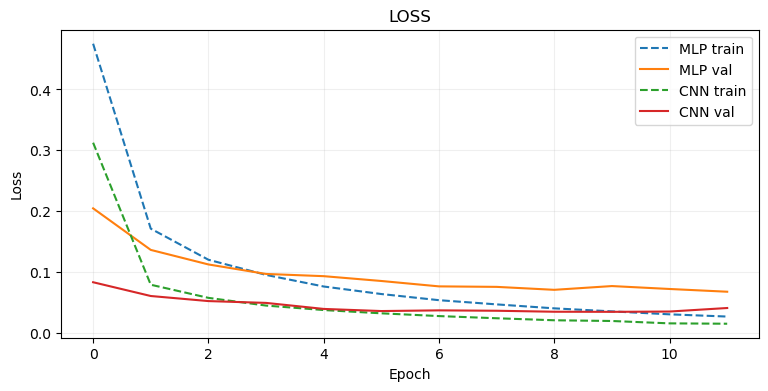

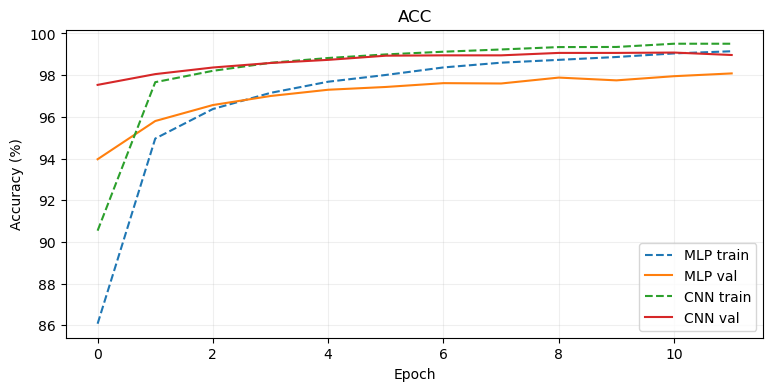


MLP test acc: 98.20%, loss 0.0606, params 535818
CNN test acc: 99.08%, loss 0.0295, params 421642


In [6]:
# ---------------------------
# Plotting utilities
# ---------------------------
def plot_histories(histories, metric='loss'):
    plt.figure(figsize=(9,4))
    for label, h in histories.items():
        if metric=='loss':
            plt.plot(h['train_loss'], linestyle='--', label=f"{label} train")
            plt.plot(h['val_loss'],  linestyle='-',  label=f"{label} val")
            plt.ylabel("Loss")
        elif metric=='acc':
            plt.plot([100*x for x in h['train_acc']], linestyle='--', label=f"{label} train")
            plt.plot([100*x for x in h['val_acc']],  linestyle='-',  label=f"{label} val")
            plt.ylabel("Accuracy (%)")
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.title(metric.upper())
    plt.show()

plot_histories({'MLP': mlp_hist, 'CNN': cnn_hist}, metric='loss')
plot_histories({'MLP': mlp_hist, 'CNN': cnn_hist}, metric='acc')

# ---------------------------
# Evaluación final en test set
# ---------------------------
loss_fn = nn.CrossEntropyLoss()
mlp_test_loss, mlp_test_acc = evaluate(mlp_model, test_loader, loss_fn, DEVICE)
cnn_test_loss, cnn_test_acc = evaluate(cnn_model, test_loader, loss_fn, DEVICE)

print(f"\nMLP test acc: {mlp_test_acc*100:.2f}%, loss {mlp_test_loss:.4f}, params {count_params(mlp_model)}")
print(f"CNN test acc: {cnn_test_acc*100:.2f}%, loss {cnn_test_loss:.4f}, params {count_params(cnn_model)}")


### Interpretación de las gráficas y resultados

1. ¿Qué muestran las curvas (loss y accuracy)?
- Convergencia más rápida y mejores valores para la CNN
- Gap train-val: Ambos modelos reducen la pérdida de entrenamiento hasta valores muy bajos, pero la CNN alcanza una pérdida de validación significativamente menor que el MLP.
- Estabilidad: Las curvas de la CNN son más estables (menos ruido) en validación, lo que sugiere una dinámica de optimización más favorable: mejor conditioning y flujo de gradientes útiles.
- Rendimiento por parámetro: La CNN obtiene ~+0.88 puntos porcentuales en test-acc usando menos parámetros. Esto evidencia que la CNN es más eficiente por parámetro en este dominio.

2. ¿Por qué ocurre esto?
- Inductive bias espacial (convoluciones): la CNN incorpora el prior de que imágenes tienen estructura local (vecindad, translational invariance). El weight sharing y los kernels locales obligan a aprender filtros reutilizables que capturan bordes y patrones locales, lo que mejora la sample efficiency — explica por qué con menos parámetros la CNN generaliza mejor que el MLP.
- Menor riesgo de over-parametrización perjudicial: aunque el MLP tiene más parámetros, muchos son redundantes para una tarea que beneficia del tratamiento espacial. Más parámetros no implican necesariamente mejor generalización si el modelo no incorpora el principio correcto.
- Conditioning y dinámica del gradiente: al explotar estructura local y agrupación jerárquica, las CNNs tienden a presentar una mejor distribución de señales en las capas (mejor conditioning) lo que facilita el descenso por gradiente. Prince y d2l enfatizan que architectures que preservan y propagan bien las señales (previniendo saturación o pérdidas de información) tienen entrenamiento más estable.
- Regularización implícita del diseño arquitectónico: las convoluciones actúan como una regularización estructural (no explícita) — obligan a la red a aprender ciertos patrones repetitivos en lugar de memorizar pixeles.

3. ¿Qué concluyen la tabla de arriba?
- El 0.88% de mejora en test-accuracy y la mitad del test-loss (0.0295 vs 0.0606) muestran que la CNN no sólo es marginalmente mejor, sino claramente superior para MNIST bajo esta configuración.
- La diferencia es suficiente para afirmar que la inductive bias de la CNN es relevante incluso en una tarea relativamente simple como MNIST.



Ejemplos MLP:


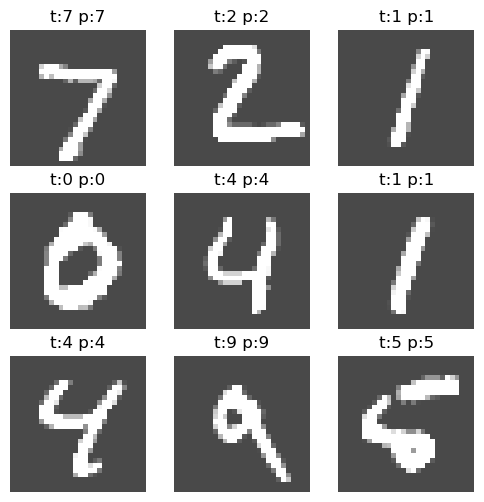

Ejemplos CNN:


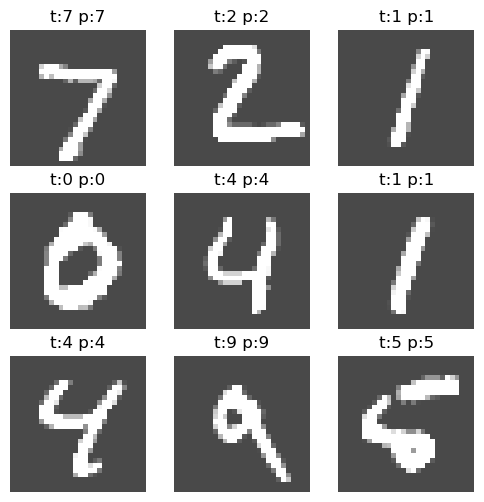

In [7]:
# ---------------------------
# Mostrar ejemplos de predicción
# ---------------------------
def show_predictions(model, loader, device, n=9):
    """
    Muestra n predicciones del loader (test).
    Si la imagen ya está normalizada (mean/std), se mostrará en escala aproximada.
    """
    model.eval()
    images, targets, preds = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            p = logits.argmax(dim=1)
            images.append(xb.cpu())
            targets.append(yb.cpu())
            preds.append(p.cpu())
            if len(images)*xb.size(0) >= n:
                break
    imgs = torch.cat(images)[:n]
    targs = torch.cat(targets)[:n]
    pds = torch.cat(preds)[:n]
    plt.figure(figsize=(6,6))
    for i in range(n):
        plt.subplot(3,3,i+1)
        plt.imshow(imgs[i].squeeze(0), cmap='gray', vmin=-1, vmax=1)
        plt.title(f"t:{int(targs[i])} p:{int(pds[i])}")
        plt.axis('off')
    plt.show()

print("Ejemplos MLP:")
show_predictions(mlp_model, test_loader, DEVICE, n=9)
print("Ejemplos CNN:")
show_predictions(cnn_model, test_loader, DEVICE, n=9)
